In [1]:
import sys
sys.path.append("/home/a379i/Scripts")   # path to folder containing the python file

from utils.load_gtf_cgc_dresden import *
from ProteinExpression.load_pr_data import *


/home/a379i/Scripts/utils/load_gtf_cgc_dresden.py:106: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Extended predisp' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  cgc.loc[cgc["geneID_short"].isin(extended_dresden_dt["geneID_short"]), "Predisposition"] = "Extended predisp"


In [2]:
import pandas as pd
import polars as pl
import plotnine as pn
import os
import numpy as np
from scipy.stats import beta
from itables import init_notebook_mode
import gzip

init_notebook_mode(all_interactive=True)


In [3]:
sa = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/sample_data/master_drop_sample_annotation_sizeFactorFiltered_0.1.tsv", sep="\t")
sa

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [4]:
impact_rank = {
    "HIGH": 3,
    "MODERATE": 2,
    "LOW": 1,
    "MODIFIER": 0
}

def collapse_variants(df, impact_col="IMPACT"):
    return (
        df
        .assign(impact_rank=df[impact_col].map(impact_rank))
        .sort_values("impact_rank", ascending=False)
        .drop_duplicates(subset=["Gene", "sampleID", "#Uploaded_variation"])
        .drop(columns="impact_rank")
    )

In [5]:
predisposition_genes = dresden_dt["geneID_short"].tolist()
extended_pre_gene = extended_dresden_dt[extended_dresden_dt["geneID_short"].notna()]["geneID_short"].tolist()
len(predisposition_genes), len(extended_pre_gene)

(141, 246)

In [13]:
# Load only relevant columns for SNVs
# p
snv_cols = [
    "Gene", "sampleID", "IMPACT", "Consequence",
    "ANNOTATION_control", "Location", #"promoterAI", "ref", "gnomADe_AF"
    "Allele", "#Uploaded_variation", "am_class", "SpliceAI_pred", "CADD_PHRED",
]

snv_variants = (
    pl.read_csv(
        #"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated_hg38/vep_res_rare_snv_all_aggregated_unique_variant_type_hg38_promoterAI.tsv",
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/vep_res_rare_snv_all_aggregated_unique_variants.tsv",
    schema_overrides={
            "sampleID": pl.String,
        },
        separator="\t",
        columns=snv_cols
    )
    .filter(pl.col("Gene").is_in(extended_pre_gene))
    .with_columns(pl.lit("snv").alias("variant_type"))
)


            



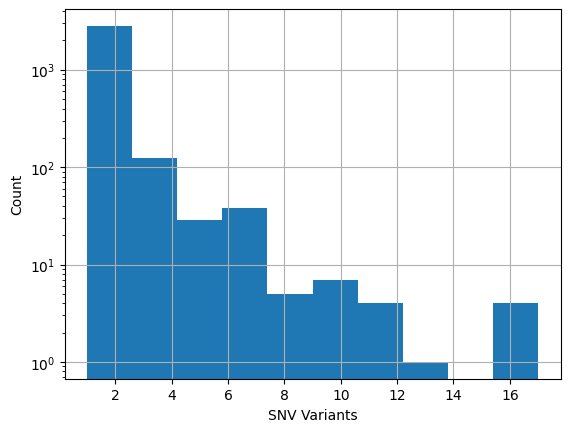

In [47]:
ax = py_or_res_aberrant[(py_or_res_aberrant["padjust_predisp_extended"] < 0.05) & (py_or_res_aberrant["ANNOTATION_control"].str.contains("germline"))]["#Uploaded_variation"].value_counts().hist(log=True)
ax.set_xlabel('SNV Variants')
ax.set_ylabel('Count')

plt.show()

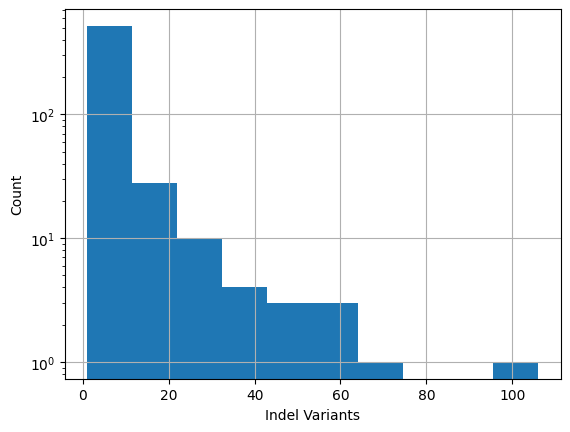

In [49]:
ax = py_or_res_aberrant[py_or_res_aberrant["padjust_predisp_extended"] < 0.05]["Location_indel"].value_counts().hist(log=True)
ax.set_xlabel('Indel Variants')
ax.set_ylabel('Count')

plt.show()

In [6]:
indel_cols = [
    "Gene", "sampleID", "IMPACT", "Consequence", "VAF",
    "ANNOTATION_control", "Location", "Allele", "am_class", "SpliceAI_pred", "CADD_PHRED", "#Uploaded_variation", "gnomADe_AF",
]

indel_variants = (
    pl.read_csv(
        "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/vep_res_rare_indel_all_aggregated_unique_variants_VAF.tsv",
        separator="\t",
        columns=indel_cols,
        infer_schema_length=100000
    )
    .filter(pl.col("Gene").is_in(extended_pre_gene))
    .with_columns(pl.lit("indel").alias("variant_type"))
)


In [7]:
print(indel_variants.shape)
indel_variants = indel_variants.filter(pl.col("VAF") > 0.1, pl.col("gnomADe_AF") <= 0.001 )
print(indel_variants.shape)


(431636, 14)
(400953, 14)


In [8]:
indel_variants

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [46]:
indel_variants.group_by(["Gene", "sampleID"]).len().sort("len", descending=True)
indel_variants.filter(pl.col("Gene") == "ENSG00000159216", pl.col("sampleID") == "7VA3P7")


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [44]:
snv_variants.shape

(1478587, 13)

In [58]:
snv_variants = snv_variants.to_pandas()
indel_variants = indel_variants.to_pandas()

snv_collapsed = collapse_variants(snv_variants)[
    ["Gene", "sampleID", "IMPACT", "Consequence", "ANNOTATION_control", "promoterAI", "Location", "Allele", "ref", 
     "#Uploaded_variation", "am_class", "SpliceAI_pred", "CADD_PHRED"]
].rename(columns={
    "IMPACT": "IMPACT_snv",
    "Consequence": "Consequence_snv",
    "ANNOTATION_control": "ANNOTATION_control_snv",
    "promoterAI": "promoterAI_snv",
    "Location": "Location_snv",
    "Allele": "Allele_snv",
    "ref": "ref_snv",
    "#Uploaded_variation": "#Uploaded_variation_snv",
    "am_class": "am_class_snv", "SpliceAI_pred": "SpliceAI_pred_snv",
    "CADD_PHRED": "CADD_PHRED_snv", "gnomADe_AF": "gnomADe_AF_snv"
})

indel_collapsed = collapse_variants(indel_variants)[
    ["Gene", "sampleID", "IMPACT", "Consequence", "ANNOTATION_control", "Location", "Allele",
    "am_class", "SpliceAI_pred", "CADD_PHRED"]
].rename(columns={
    "IMPACT": "IMPACT_indel",
    "Consequence": "Consequence_indel",
    "ANNOTATION_control": "ANNOTATION_control_indel",
    "Location": "Location_indel",
    "Allele": "Allele_indel",
    "am_class": "am_class_indel",
    "SpliceAI_pred": "SpliceAI_pred_indel",
    "CADD_PHRED": "CADD_PHRED_indel", "gnomADe_AF": "gnomADe_AF_indel"
})


In [71]:
# all_predispostion_vars = pd.concat((snv_collapsed, indel_collapsed))
# all_predispostion_vars.to_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/unique_predispostion.tsv", sep="\t", index=None)
all_predispostion_vars = pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/unique_predispostion.tsv", sep="\t")
all_predispostion_vars.shape


/tmp/ipykernel_2558935/2906077216.py:3: DtypeWarning:

Columns (2,3,4,6,7,8,9,10,11,13,14,15,16,17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.



(664796, 21)

# get some plots

In [16]:
all_predispostion_vars = all_predispostion_vars.merge(sa, left_on="sampleID", right_on="pid")



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


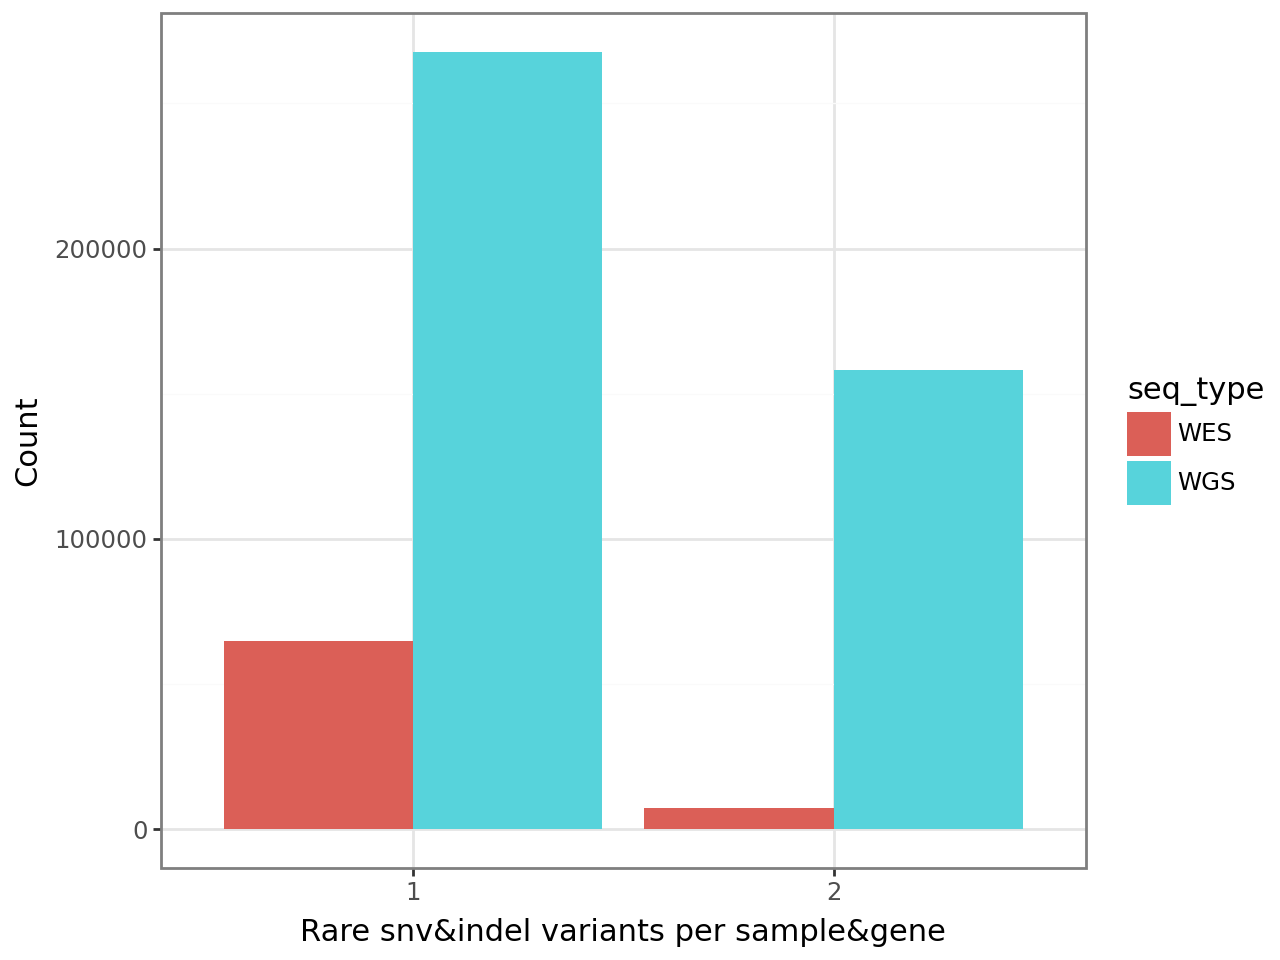

In [35]:
# count occurrences of each (Gene, sampleID) pair
counts = (
    all_predispostion_vars[["Gene", "sampleID"]]
    .value_counts()
    .reset_index(name="n")
)
counts = counts.merge(sa, left_on="sampleID", right_on = "pid")
counts["n"] = counts["n"].astype(str)

# histogram of the counts
p = (
    pn.ggplot(counts, pn.aes(x="n", fill="seq_type"))
    + pn.geom_col(stat="count", position="dodge")
    + pn.labs(
        x="Rare snv&indel variants per sample&gene",
        y="Count"
    )
    #+ pn.scale_y_log()
    + pn.theme_bw()
)

p

In [6]:
germline = all_predispostion_vars[(all_predispostion_vars["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
                        (all_predispostion_vars["ANNOTATION_control_indel"].str.contains("germline", na=False))]
germline.shape 

(568860, 21)

In [7]:
germline_high = germline[((germline["ANNOTATION_control_snv"].str.contains("germline", na=False)) & (germline["IMPACT_snv"] == "HIGH")) |
         ((germline["ANNOTATION_control_indel"].str.contains("germline", na=False)) & (germline["IMPACT_indel"] == "HIGH"))]
germline_high.shape

(1913, 21)

In [8]:
germline_nothigh = germline[(germline["IMPACT_snv"] != "HIGH") & (germline["IMPACT_indel"] != "HIGH")]
germline_nothigh.shape

(566947, 21)

# Aberrant Expression

In [51]:
needed_cols = ["sampleID", "zScore", "pValue", "padjust", "IMPACT", "geneID",  "geneID_short",
               "#Uploaded_variation_snv", "ref_snv", "Allele_snv", "IMPACT_snv", "ANNOTATION_control_snv", "Consequence_snv", "promoterAI_snv",
               "Location_indel", "IMPACT_indel", "ANNOTATION_control_indel", "Consequence_indel",
               "padjust_predisp", "padjust_predisp_extended", ]

py_or_res_aberrant = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/or_variants_outliers.parquet",
                                    columns=needed_cols)
py_or_res_aberrant = py_or_res_aberrant.merge(sa[["pid", "Diag", "Oncotree Code", "Oncotree Text", "seq_type"]], right_on="pid", left_on="sampleID")
py_or_res_aberrant = py_or_res_aberrant.merge(extended_dresden_dt, on="geneID_short")
py_or_res_aberrant["chrom_snv"] = py_or_res_aberrant["#Uploaded_variation_snv"].str.split("_").str[0]
py_or_res_aberrant["pos_snv"] = py_or_res_aberrant["#Uploaded_variation_snv"].str.split("_").str[1]

py_or_res_aberrant["gene_sample"] = py_or_res_aberrant["geneID_short"] + "_" + py_or_res_aberrant["sampleID"]



In [41]:
py_or_res_aberrant = py_or_res_aberrant[py_or_res_aberrant["ANNOTATION_control"].str.contains("germline", na=True)]
py_or_res_aberrant
ata


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/tmp/ipykernel_1654763/1037526182.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


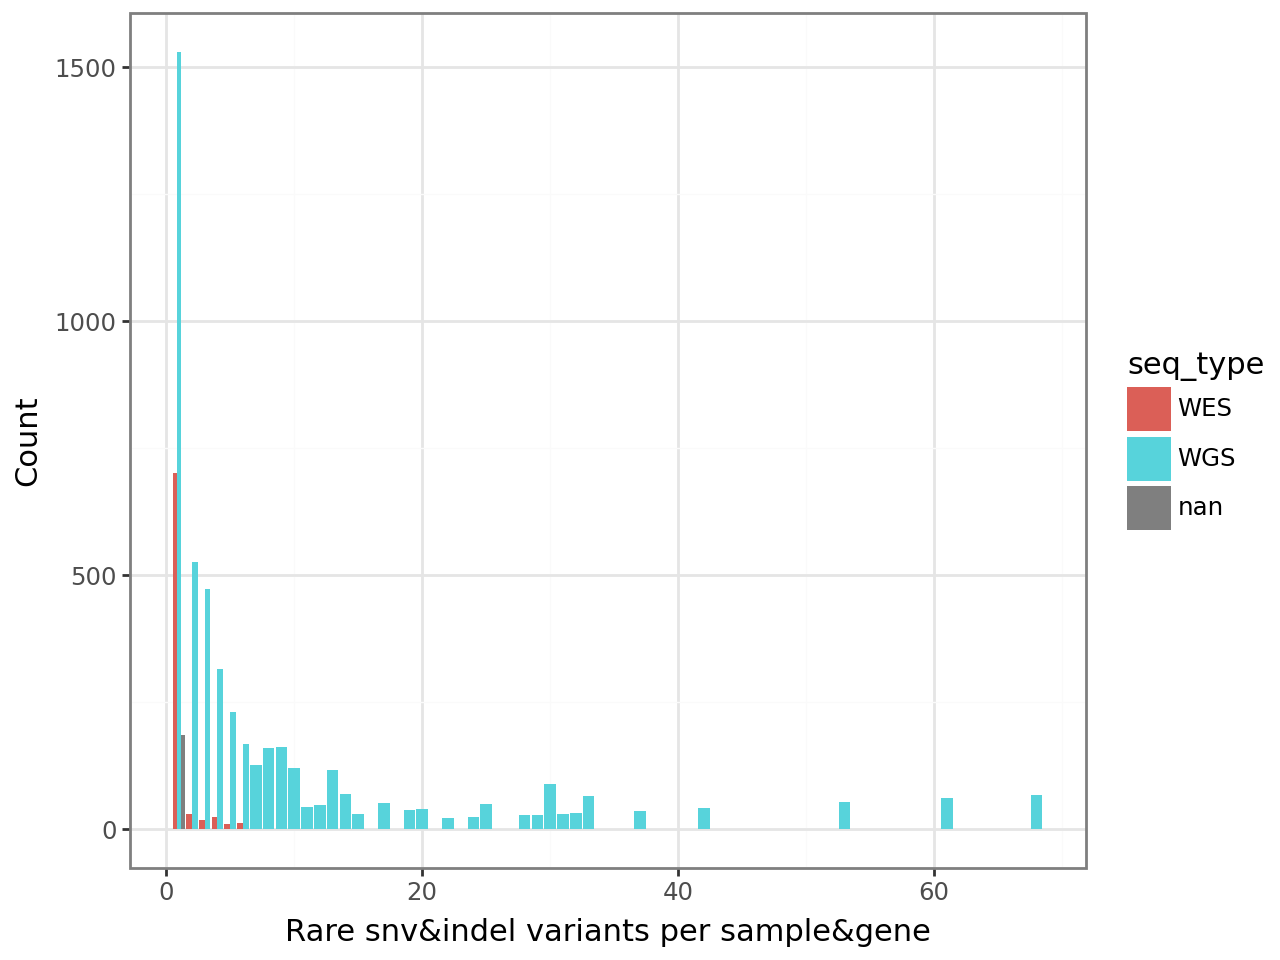

In [39]:
py_or_res_aberrant["num_variants"] = (
    py_or_res_aberrant
        .groupby("gene_sample")["gene_sample"]
        .transform("size")
)

pie_df = (
    py_or_res_aberrant["num_variants"]
      .value_counts()
      .sort_index()
      .reset_index()
)



# histogram of the counts
p = (
    pn.ggplot(py_or_res_aberrant, pn.aes(x="num_variants", fill="seq_type"))
    + pn.geom_col(stat="count", position="dodge")
    + pn.labs(
        x="Rare snv&indel variants per sample&gene",
        y="Count"
    )
    #+ pn.scale_y_log()
    + pn.theme_bw()
)

p

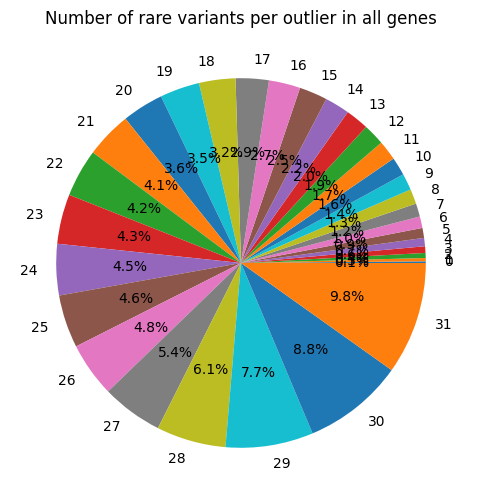

In [40]:
import matplotlib.pyplot as plt
pie_df['num_variants'].plot.pie(
    autopct='%1.1f%%', 
    figsize=(6, 6),
    ylabel='', # Removes the awkward 'n' label on the side
    title="Number of rare variants per outlier in all genes"
)
plt.show()

In [53]:
#germline_nothigh["gene_sample"] = germline_nothigh["Gene"] + "_" + germline_nothigh["sampleID"]
#germline_high["gene_sample"] = germline_high["Gene"] + "_" + germline_high["sampleID"]
# snv_variants["gene_sample"] = snv_variants["Gene"] + "_" + snv_variants["sampleID"]

In [63]:
or_var_merged = germline_high.merge(py_or_res_aberrant, how="left", on="gene_sample")
or_var_merged[(or_var_merged["padjust_predisp_extended"] <= 0.05) & (or_var_merged["zScore"] < 0)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [64]:
or_nothigh_merged = germline_nothigh.merge(py_or_res_aberrant, how="left", on="gene_sample")
or_nothigh_merged[(or_nothigh_merged["padjust_predisp_extended"] <= 0.05) & (or_nothigh_merged["zScore"] < 0)]
#or_nothigh_merged[(or_nothigh_merged["padjust_predisp_extended"] <= 0.05) & (or_nothigh_merged["zScore"] < 0) & (or_nothigh_merged["promoterAI_snv_x"] <= 0)][["sampleID_x", "IMPACT_snv_x", "chrom_snv", "pos_snv", "ref_snv_x", "Allele_snv_x", "gene_name", "padjust_predisp_extended", "promoterAI_snv_x", "Diag", "Oncotree Code", "Oncotree Text"]]
# or_nothigh_merged[(or_nothigh_merged["padjust_predisp_extended"] <= 0.05) & (or_nothigh_merged["zScore"] < 0) & (or_nothigh_merged["am_class_snv"] == "pathogenic")][["sampleID_x", "chrom_snv", "pos_snv", "ref_snv_x", "Allele_snv_x", "gene_name", "padjust_predisp_extended", "am_class_snv", "Diag", "Oncotree Code", "Oncotree Text"]].rename(columns={"Allele_snv_x": "alt_snv"})
#or_nothigh_merged[(or_nothigh_merged["padjust_predisp_extended"] <= 0.05) & (or_nothigh_merged["zScore"] > 0) & (or_nothigh_merged["promoterAI_snv_x"] <= 0)][["sampleID_x", "IMPACT_snv_x", "chrom_snv", "pos_snv", "ref_snv_x", "Allele_snv_x", "gene_name", "padjust_predisp_extended", "promoterAI_snv_x", "Diag", "Oncotree Code", "Oncotree Text"]]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# proteomics

In [10]:

pr_or_res_aberrant = pd.read_parquet("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/protrider_runs/output_cov_gaussian_gs_lr_0_001_epoc2000_noInitPCA/pr_varinats_outliers.parquet")
pr_or_res_aberrant = pr_or_res_aberrant.merge(sa[["pid", "Diag", "Oncotree Code", "Oncotree Text"]], right_on="pid", left_on="sampleID")

pr_or_res_aberrant["chrom_snv"] = pr_or_res_aberrant["#Uploaded_variation_snv"].str.split("_").str[0]
pr_or_res_aberrant["pos_snv"] = pr_or_res_aberrant["#Uploaded_variation_snv"].str.split("_").str[1]

In [58]:
all_predispostion_vars[all_predispostion_vars["sampleID"].isin(sa[sa["proteomics"] == True].pid)].shape
all_predispostion_vars[(all_predispostion_vars["sampleID"].isin(sa[sa["proteomics"] == True].pid)) & 
                    ((all_predispostion_vars["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
                        (all_predispostion_vars["ANNOTATION_control_indel"].str.contains("germline", na=False)))].shape
all_predispostion_vars[((all_predispostion_vars["IMPACT_snv"] == "HIGH") | (all_predispostion_vars["IMPACT_indel"] == "HIGH")) & 
                    (all_predispostion_vars["sampleID"].isin(sa[sa["proteomics"] == True].pid)) & 
                    ((all_predispostion_vars["ANNOTATION_control_snv"].str.contains("germline", na=False)) |
                        (all_predispostion_vars["ANNOTATION_control_indel"].str.contains("germline", na=False)))].shape

(545, 21)

In [13]:
pr_or_res_aberrant["gene_sample"] = pr_or_res_aberrant["geneID_short"] + "_" + pr_or_res_aberrant["sampleID"]


In [15]:
pr_var_merged_high = germline_high.merge(pr_or_res_aberrant, how="left", on="gene_sample")
pr_var_merged_high[(pr_var_merged_high["padjust_predisp_extended"] <= 0.05) & (pr_var_merged_high["zScore"] < 0)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [16]:
pr_or_var_high = pr_var_merged_high.merge(py_or_res_aberrant, how="left", on="gene_sample")
pr_or_var_high[(pr_or_var_high["padjust_predisp_extended_x"] <= 0.1) & (pr_or_var_high["padjust_predisp_extended_y"] <= 0.05)][["sampleID_x", "zScore_x", "zScore_y", "IMPACT_snv_x", "chrom_snv_x", "pos_snv_x", "ref_snv_x", "Allele_snv_x", "gene_name_x", "padjust_predisp_extended_x", "promoterAI_snv_x", "am_class_snv", "Diag_x", "Oncotree Code_x", "Oncotree Text_x"]]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [27]:
pr_nothigh_merged = germline_nothigh.merge(pr_or_res_aberrant, how="left", on="gene_sample")
pr_nothigh_merged[(pr_nothigh_merged["padjust_predisp_extended"] <= 0.05) & (pr_nothigh_merged["zScore"] < 0) & (pr_nothigh_merged["am_class_snv"] == "pathogenic")][["sampleID_x", "IMPACT_snv_x", "chrom_snv", "pos_snv", "ref_snv", "Allele_snv", "gene_name", "padjust_predisp_extended", "promoterAI_snv_x", "am_class_snv", "Diag", "Oncotree Code", "Oncotree Text"]]
pr_nothigh_merged[(pr_nothigh_merged["padjust_predisp_extended"] <= 0.1) & (pr_nothigh_merged["zScore"] < 0) & ((pr_nothigh_merged["Consequence_snv_x"].str.contains("missense_variant")) |  (pr_nothigh_merged["Consequence_indel_x"].str.contains("missense_variant")))][["sampleID_x", "Consequence_snv_x", "IMPACT_snv_x", "chrom_snv", "pos_snv", "ref_snv", "Allele_snv", "gene_name", "am_class_snv", "Oncotree Code","Diag", "Oncotree Text"]]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [54]:
pr_or_var_merged_nothigh = pr_nothigh_merged.merge(py_or_res_aberrant, how="left", on="gene_sample")
pr_or_var_merged_nothigh[(pr_or_var_merged_nothigh["padjust_predisp_extended_x"] <= 0.1) & (pr_or_var_merged_nothigh["padjust_predisp_extended_y"] < 0.05)
    & (pr_or_var_merged_nothigh["zScore_x"] < 0) & (pr_or_var_merged_nothigh["zScore_y"] > 0)]



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Splicing 

In [10]:
fr_res =  pd.read_csv("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_splicing/results/v19/fraser/aggregated_outliers_variants.tsv", sep="\t")

fr_res = pd.merge(fr_res, dresden_dt_cgc[["gene_name", "gene_type", "geneID_short", "ROLE_IN_CANCER", "predisposition_gene"]], on="geneID_short", how="left")
fr_res = pd.merge(fr_res, sa, left_on="sampleID", right_on="pid")


In [13]:
fr_res_predisp = fr_res[fr_res["predisposition_gene"] == True]

In [34]:
splice_high = ["splice_acceptor_variant", "splice_donor_variant"]

In [47]:
germline_splicing_high = germline[((germline["ANNOTATION_control_snv"].str.contains("germline", na=False)) & 
                                   ((germline["Consequence_snv"].str.contains(splice_high[0])) | (germline["Consequence_snv"].str.contains(splice_high[1])))) |
         ((germline["ANNOTATION_control_indel"].str.contains("germline", na=False)) & 
          (germline["Consequence_indel"].str.contains(splice_high[0])) | (germline["Consequence_indel"].str.contains(splice_high[1])))]
germline_splicing_high.shape

(797, 21)

In [52]:
germline_splicing_nothigh = germline[~germline.index.isin(germline_splicing_high.index)]
germline_splicing_nothigh.shape

(568063, 21)

In [53]:
germline_splicing_nothigh["gene_sample"] = germline_splicing_nothigh["Gene"] + "_" + germline_splicing_nothigh["sampleID"]
fr_res["gene_sample"] = fr_res["geneID_short"] + "_" + fr_res["sampleID"]
fr_res_predisp["gene_sample"] = fr_res_predisp["geneID_short"] + "_" + fr_res_predisp["sampleID"]

germline_splicing_high["gene_sample"] = germline_splicing_high["Gene"] + "_" + germline_splicing_high["sampleID"]

/tmp/ipykernel_802796/3354078562.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/3354078562.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/3354078562.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [89]:
splicing_var_merged_high = germline_splicing_high.merge(fr_res_predisp, how="left", on="gene_sample")
splicing_var_merged_high[(splicing_var_merged_high["padjust"] <= 0.1)]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [69]:
tmp = germline_splicing_nothigh["SpliceAI_pred_snv"].str.split("|", expand=True)

# assign delta scores
germline_splicing_nothigh["SpliceAI_DS_AG"] = pd.to_numeric(tmp[1], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_AL"] = pd.to_numeric(tmp[2], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_DG"] = pd.to_numeric(tmp[3], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_DL"] = pd.to_numeric(tmp[4], errors="coerce")

# max delta score
germline_splicing_nothigh["SpliceAI_DS_max"] = germline_splicing_nothigh[
    ["SpliceAI_DS_AG","SpliceAI_DS_AL","SpliceAI_DS_DG","SpliceAI_DS_DL"]
].max(axis=1)

/tmp/ipykernel_802796/3212218469.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/3212218469.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/3212218469.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_8027

In [73]:
tmp = germline_splicing_nothigh["SpliceAI_pred_indel"].str.split("|", expand=True)

# assign delta scores
germline_splicing_nothigh["SpliceAI_DS_AG_indel"] = pd.to_numeric(tmp[1], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_AL_indel"] = pd.to_numeric(tmp[2], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_DG_indel"] = pd.to_numeric(tmp[3], errors="coerce")
germline_splicing_nothigh["SpliceAI_DS_DL_indel"] = pd.to_numeric(tmp[4], errors="coerce")

# max delta score
germline_splicing_nothigh["SpliceAI_DS_max_indel"] = germline_splicing_nothigh[
    ["SpliceAI_DS_AG_indel","SpliceAI_DS_AL_indel","SpliceAI_DS_DG_indel","SpliceAI_DS_DL_indel"]
].max(axis=1)

/tmp/ipykernel_802796/1434365005.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/1434365005.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_802796/1434365005.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/tmp/ipykernel_8027

In [88]:
splicing_var_merged_nothigh = germline_splicing_nothigh.merge(fr_res_predisp, how="left", on="gene_sample")
splicing_var_merged_nothigh[(splicing_var_merged_nothigh["padjust"].notna()) & (splicing_var_merged_nothigh["am_class_snv"] == "pathogenic")]
splicing_var_merged_nothigh[(splicing_var_merged_nothigh["padjust"].notna()) & (abs(splicing_var_merged_nothigh["promoterAI_snv_x"]) >= 0.1)]
splicing_var_merged_nothigh[(splicing_var_merged_nothigh["padjust"].notna()) & 
    ((abs(splicing_var_merged_nothigh["SpliceAI_DS_max"]) >= 0.5) | (abs(splicing_var_merged_nothigh["SpliceAI_DS_max_indel"]) >= 0.5))][["sampleID_x", "Oncotree Code", "gene_name_x", "SpliceAI_DS_max", "deltaPsi", "padjust", "Consequence_snv_x"]]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [92]:
splicing_var_merged_nothigh[(splicing_var_merged_nothigh["padjust"].notna()) & (splicing_var_merged_nothigh["Consequence_indel_x"].str.contains("spl"))]

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


# Activation

In [7]:
mu = 5
theta = 100
activation_res = pd.read_csv(f"/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/nb_act/activation_res_protein_coding_genes_sig_theta{theta}_mu{mu}_BH.tsv", sep="\t")

activation_res = activation_res.merge(sa[["pid", "Diag", "Oncotree Code", "SEX", "ICD10 Code", "TISSUE", "Tumorzellgehalt (Bioinformatik)"]], how="left", left_on="sampleID", right_on= "pid")

activation_res = activation_res.merge(gene_annot_dt, left_on="geneID", right_on = "gene_id")

activation_res["aberrant"] = True



In [10]:
activation_predisp = activation_res[activation_res["gene_name"].isin(extended_dresden_dt_cgc["gene_name"])]

In [16]:
germline.head()

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [28]:
germline_act = germline.merge(activation_predisp, how="left", left_on=["Gene", "sampleID"], right_on=["geneID_short", "sampleID"])
germline_act[(germline_act["aberrant"] == True)]


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
